In [9]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import datasets, transforms, models
from sklearn.manifold import TSNE


In [10]:
# Настройки
SEED = 42
EPOCHS = 10
BATCH_SIZE = 64
NUM_WORKERS = 2
EMB_DIM = 128
LR = 1e-3
WEIGHT_DECAY = 1e-4
MARGIN = 0.4
SCALE = 30.0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [11]:
# -------------------------
# Dataset helpers
# -------------------------
class TransformedSubset(Dataset):
    # Подвыборка из датасета + свой transform
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image, label = self.base_dataset[real_idx]

        if self.transform is not None:
            image = self.transform(image)

        return image, label


def make_train_val_test_indices(labels, val_ratio=0.1, test_ratio=0.2, seed=42):
    np.random.seed(seed)

    labels = np.array(labels)

    train_idx = []
    val_idx = []
    test_idx = []

    classes = np.unique(labels)

    for cls in classes:
        cls_indices = np.where(labels == cls)[0]
        np.random.shuffle(cls_indices)

        n = len(cls_indices)
        n_test = int(n * test_ratio)
        n_val = int(n * val_ratio)

        test_part = cls_indices[:n_test]
        val_part = cls_indices[n_test:n_test + n_val]
        train_part = cls_indices[n_test + n_val:]

        test_idx.extend(test_part)
        val_idx.extend(val_part)
        train_idx.extend(train_part)

    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)
    np.random.shuffle(test_idx)

    return train_idx, val_idx, test_idx


In [12]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

EUROSAT_LOCAL_ROOT = Path("./2750")
DATA_ROOT = Path("./data")
EUROSAT_FALLBACK_ROOT = DATA_ROOT / "EuroSAT"

base_dataset = None

if EUROSAT_LOCAL_ROOT.exists():
    base_dataset = datasets.ImageFolder(root=str(EUROSAT_LOCAL_ROOT), transform=None)
elif EUROSAT_FALLBACK_ROOT.exists():
    base_dataset = datasets.ImageFolder(root=str(EUROSAT_FALLBACK_ROOT), transform=None)
else:
    base_dataset = datasets.EuroSAT(root=str(DATA_ROOT), download=True, transform=None)

class_names = base_dataset.classes
output_classes = len(class_names)

all_labels = [base_dataset[i][1] for i in range(len(base_dataset))]

train_indices, val_indices, test_indices = make_train_val_test_indices(
    all_labels,
    val_ratio=0.1,
    test_ratio=0.2,
    seed=SEED
)

train_dataset = TransformedSubset(base_dataset, train_indices, transform=train_transform)
val_dataset = TransformedSubset(base_dataset, val_indices, transform=test_transform)
test_dataset = TransformedSubset(base_dataset, test_indices, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Classes:", output_classes)
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Classes: 10
Train: 18900
Val: 2700
Test: 5400


In [13]:
# -------------------------
# ArcFace components
# -------------------------
class CosineComponent(nn.Module):
    def __init__(self, emb_size, output_classes):
        super().__init__()
        self.W = nn.Parameter(torch.Tensor(emb_size, output_classes))
        nn.init.kaiming_uniform_(self.W)

    def forward(self, x):
        x_norm = F.normalize(x, dim=1)
        W_norm = F.normalize(self.W, dim=0)
        return x_norm @ W_norm


def arcface_loss(cosine, target, m=0.4, s=30.0):
    # чтобы не было nan
    cosine = cosine.clamp(-1 + 1e-7, 1 - 1e-7)

    # угол
    arcosine = torch.acos(cosine)

    # добавляем margin только правильному классу
    one_hot = F.one_hot(target, num_classes=cosine.size(1)).float()
    arcosine = arcosine + one_hot * m

    # обратно в cosine
    cosine2 = torch.cos(arcosine)

    # scale
    logits = cosine2 * s

    return F.cross_entropy(logits, target)


In [14]:
class ArcFaceNet(nn.Module):
    def __init__(self, output_classes, emb_dim=128):
        super().__init__()

        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.backbone = backbone
        self.embedding = nn.Linear(in_features, emb_dim)
        self.head = CosineComponent(emb_dim, output_classes)

    def forward(self, x):
        feat = self.backbone(x)
        emb = self.embedding(feat)
        emb = F.normalize(emb, dim=1)
        cosine_logits = self.head(emb)
        return emb, cosine_logits


model = ArcFaceNet(output_classes=output_classes, emb_dim=EMB_DIM).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [15]:
# -------------------------
# Train / Eval loops
# -------------------------
def run_epoch(model, loader, optimizer=None, m=0.4, s=30.0):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            emb, cosine_logits = model(images)
            loss = arcface_loss(cosine_logits, labels, m=m, s=s)

            if is_train:
                loss.backward()
                optimizer.step()

        preds = cosine_logits.argmax(dim=1)

        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total_count += images.size(0)

    avg_loss = total_loss / total_count
    avg_acc = total_correct / total_count
    return avg_loss, avg_acc


history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer, m=MARGIN, s=SCALE)
    val_loss, val_acc = run_epoch(model, val_loader, optimizer=None, m=MARGIN, s=SCALE)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
    )


Epoch 1/10 | train_loss=3.1512 | train_acc=0.8760 | val_loss=3.0981 | val_acc=0.8756
Epoch 2/10 | train_loss=1.8123 | train_acc=0.9283 | val_loss=1.8222 | val_acc=0.9267
Epoch 3/10 | train_loss=1.5729 | train_acc=0.9357 | val_loss=1.3460 | val_acc=0.9422
Epoch 4/10 | train_loss=1.2003 | train_acc=0.9493 | val_loss=1.0478 | val_acc=0.9556
Epoch 5/10 | train_loss=1.0951 | train_acc=0.9531 | val_loss=0.8804 | val_acc=0.9615
Epoch 6/10 | train_loss=1.0280 | train_acc=0.9553 | val_loss=1.6369 | val_acc=0.9252
Epoch 7/10 | train_loss=0.9026 | train_acc=0.9586 | val_loss=0.6471 | val_acc=0.9696
Epoch 8/10 | train_loss=0.6899 | train_acc=0.9686 | val_loss=0.8159 | val_acc=0.9615
Epoch 9/10 | train_loss=0.6346 | train_acc=0.9704 | val_loss=0.5997 | val_acc=0.9693
Epoch 10/10 | train_loss=0.5431 | train_acc=0.9736 | val_loss=1.0112 | val_acc=0.9470


In [16]:
final_test_loss, final_test_acc = run_epoch(model, test_loader, optimizer=None, m=MARGIN, s=SCALE)

print("Final test loss:", f"{final_test_loss:.4f}")
print("Final test accuracy:", f"{final_test_acc:.4f}")

Final test loss: 0.8745
Final test accuracy: 0.9544


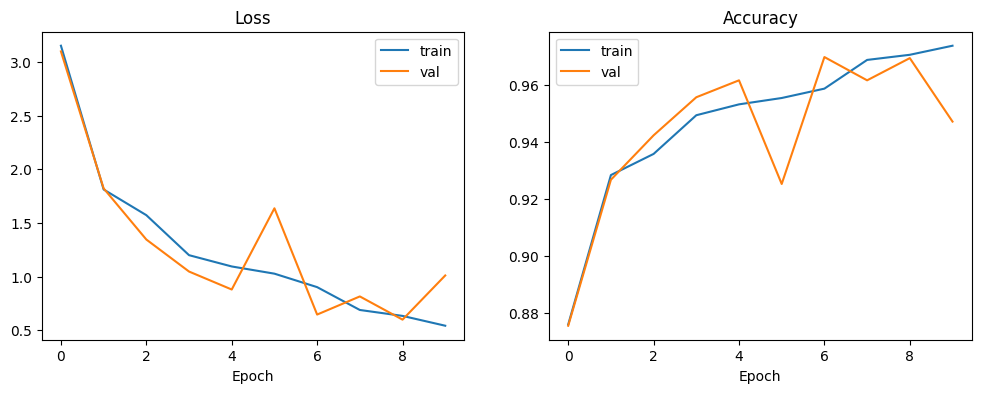

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(history["train_acc"], label="train")
ax[1].plot(history["val_acc"], label="val")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].legend()

plt.show()

Running t-SNE on 4000 samples...


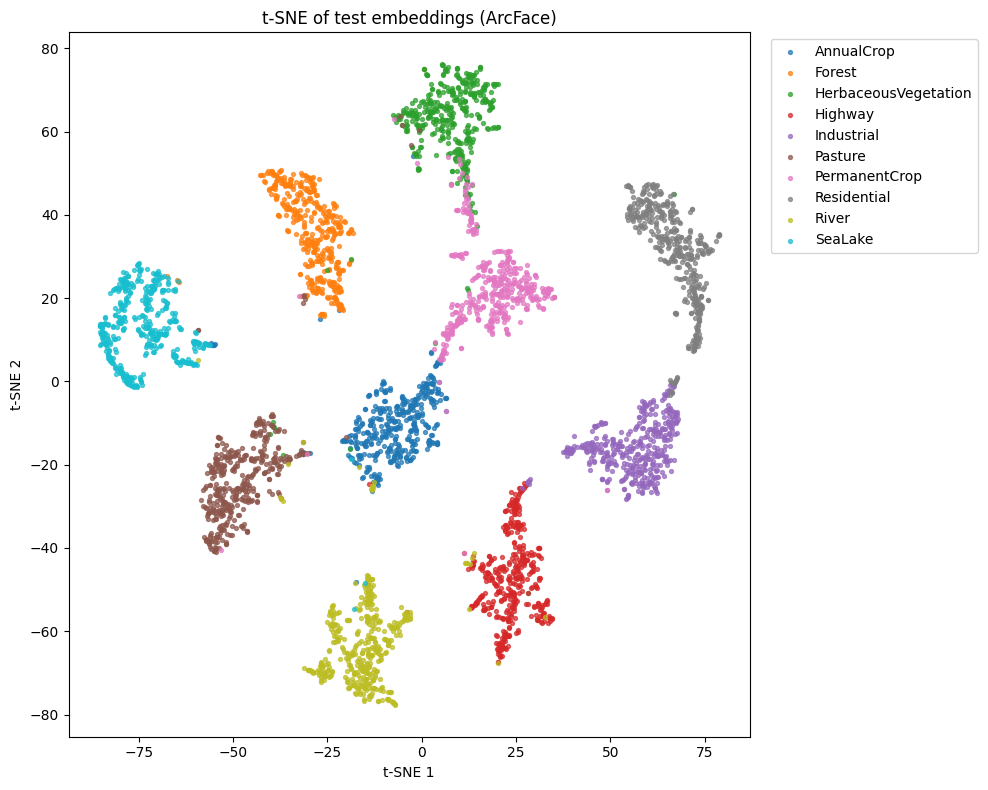

In [19]:
# -------------------------
# t-SNE on test embeddings
# -------------------------
model.eval()
all_embs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        emb, _ = model(images)
        emb = F.normalize(emb, dim=1)
        all_embs.append(emb.cpu().numpy())
        all_labels.append(labels.numpy())

all_embs = np.concatenate(all_embs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# берём одинаковое число объектов из каждого класса
rng = np.random.default_rng(SEED)
class_indices = [np.where(all_labels == class_id)[0] for class_id in range(output_classes)]
min_count = min(len(idx) for idx in class_indices)

selected_idx = []
for idx in class_indices:
    idx = idx.copy()
    rng.shuffle(idx)
    selected_idx.append(idx[:min_count])

selected_idx = np.concatenate(selected_idx)

all_embs_balanced = all_embs[selected_idx]
all_labels_balanced = all_labels[selected_idx]

print("Running t-SNE on", all_embs_balanced.shape[0], "samples...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=2000,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

emb_2d = tsne.fit_transform(all_embs_balanced)

plt.figure(figsize=(10, 8))
for class_id, class_name in enumerate(class_names):
    mask = all_labels_balanced == class_id
    if np.any(mask):
        plt.scatter(
            emb_2d[mask, 0],
            emb_2d[mask, 1],
            s=8,
            alpha=0.7,
            label=class_name
        )

plt.title("t-SNE of test embeddings (ArcFace)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# -------------------------
# Pair inference: cosine similarity + euclidean distance
# -------------------------
def get_test_raw_item(test_idx):
    # получаем исходную картинку и label из test subset
    base_idx = test_dataset.indices[test_idx]
    return base_dataset[base_idx]


def compute_embedding_from_pil(image_pil):
    model.eval()
    x = test_transform(image_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        emb, _ = model(x)

    return emb.squeeze(0)


def compare_test_pair(test_idx_1, test_idx_2):
    img1_pil, y1 = get_test_raw_item(test_idx_1)
    img2_pil, y2 = get_test_raw_item(test_idx_2)

    emb1 = compute_embedding_from_pil(img1_pil)
    emb2 = compute_embedding_from_pil(img2_pil)

    cos_sim = F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()
    euc_dist = torch.norm(emb1 - emb2, p=2).item()

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(np.array(img1_pil))
    axes[0].set_title(f"idx={test_idx_1}\nclass={class_names[y1]}")
    axes[0].axis("off")

    axes[1].imshow(np.array(img2_pil))
    axes[1].set_title(f"idx={test_idx_2}\nclass={class_names[y2]}")
    axes[1].axis("off")

    plt.suptitle(
        f"Cosine similarity: {cos_sim:.4f} | Euclidean distance: {euc_dist:.4f}",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    print(f"Pair ({test_idx_1}, {test_idx_2})")
    print(f"Class1={class_names[y1]}, Class2={class_names[y2]}")
    print(f"Cosine similarity={cos_sim:.4f}")
    print(f"Euclidean distance={euc_dist:.4f}")

    return {
        "idx1": test_idx_1,
        "idx2": test_idx_2,
        "label1": int(y1),
        "label2": int(y2),
        "cosine_similarity": cos_sim,
        "euclidean_distance": euc_dist,
    }


def find_same_and_diff_pairs(labels):
    by_class = {}
    for idx, lb in enumerate(labels):
        by_class.setdefault(int(lb), []).append(idx)

    same_pair = None
    for cls, idxs in by_class.items():
        if len(idxs) >= 2:
            same_pair = (idxs[0], idxs[1])
            break

    present_classes = [c for c, idxs in by_class.items() if len(idxs) > 0]
    if len(present_classes) < 2:
        raise RuntimeError("test set")

    c1, c2 = present_classes[0], present_classes[1]
    diff_pair = (by_class[c1][0], by_class[c2][0])

    if same_pair is None:
        raise RuntimeError("same-class")

    return same_pair, diff_pair


Same-class pair: (0, 16)


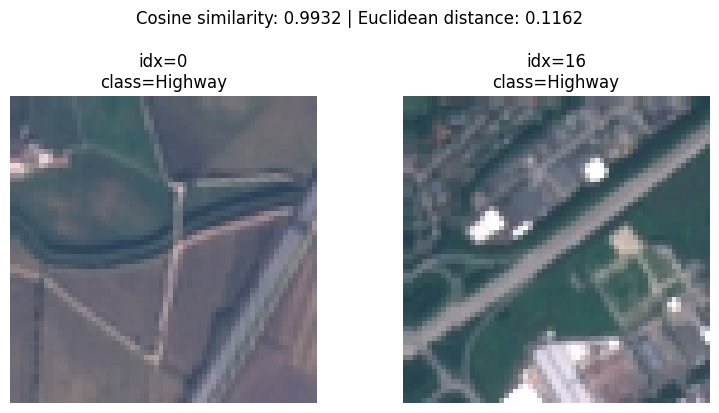

Pair (0, 16)
Class1=Highway, Class2=Highway
Cosine similarity=0.9932
Euclidean distance=0.1162

Different-class pair: (0, 1)


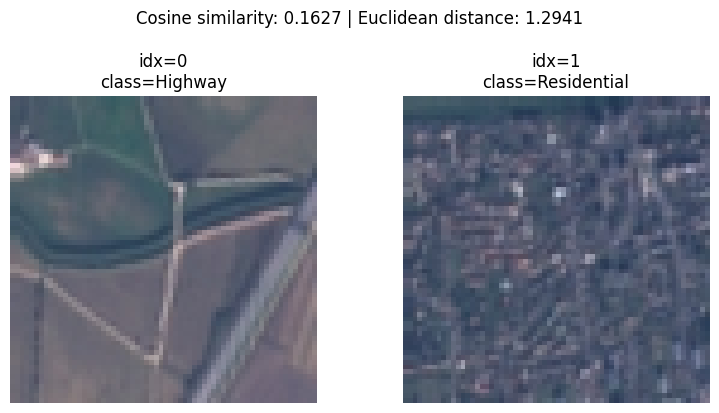

Pair (0, 1)
Class1=Highway, Class2=Residential
Cosine similarity=0.1627
Euclidean distance=1.2941


In [23]:
test_labels_for_pairs = []
for i in range(len(test_dataset)):
    _, label = test_dataset[i]
    test_labels_for_pairs.append(int(label))

same_pair, diff_pair = find_same_and_diff_pairs(test_labels_for_pairs)

print("Same-class pair:", same_pair)
same_result = compare_test_pair(*same_pair)

print("\nDifferent-class pair:", diff_pair)
diff_result = compare_test_pair(*diff_pair)


In [22]:
print("Final test accuracy:", f"{final_test_acc:.4f}")
print("Same-class pair metrics:", same_result)
print("Different-class pair metrics:", diff_result)

Final test accuracy: 0.9544
Same-class pair metrics: {'idx1': 0, 'idx2': 16, 'label1': 3, 'label2': 3, 'cosine_similarity': 0.9932482242584229, 'euclidean_distance': 0.11620500683784485}
Different-class pair metrics: {'idx1': 0, 'idx2': 1, 'label1': 3, 'label2': 7, 'cosine_similarity': 0.16269062459468842, 'euclidean_distance': 1.2940707206726074}
